# Walmart Store Sales — Prophet v6: historical blend-weight tuning

v4 is the Prophet champion (`1367.45` WMAE). v5 showed that external covariates weakened this per-series model, so v6 returns to v4's event-aware calendar and tunes only the blend weight safely.

A 26-week historical calibration period chooses alpha without using the final 39-week validation target:

```text
prediction = (1 - alpha) × SeasonalNaive52 + alpha × raw Prophet
```


In [11]:
%pip install -q "prophet>=1.1,<2" "wandb>=0.19,<1" "pandas>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4" "cloudpickle>=3,<4"

In [12]:
from __future__ import annotations
import hashlib
import json
import logging
import time
import warnings
from pathlib import Path
import cloudpickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb
from prophet import Prophet
from prophet.serialize import model_from_json, model_to_json

warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

In [13]:
try:
    from google.colab import drive

    drive.mount("/content/drive")
except Exception as exc:
    print(exc)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
SEED = 42
np.random.seed(SEED)
HOLIDAY_WINDOWS = {
    "super_bowl": (0, 0),
    "labor_day": (0, 0),
    "thanksgiving": (-7, 0),
    "christmas": (-7, 0),
}
ALPHA_GRID = np.round(np.arange(0.0, 1.01, 0.05), 2).tolist()
CONFIG = {
    "validation_weeks": 39,
    "calibration_weeks": 26,
    "holiday_weight": 5.0,
    "top_n_series": None,
    "min_history_points": 52,
    "seasonal_lag_weeks": 52,
    "alpha_grid": ALPHA_GRID,
    "growth": "linear",
    "yearly_seasonality": True,
    "weekly_seasonality": False,
    "daily_seasonality": False,
    "seasonality_mode": "additive",
    "changepoint_prior_scale": 0.05,
    "seasonality_prior_scale": 10.0,
    "holidays_prior_scale": 10.0,
    "prediction_clip_min": 0.0,
    "prediction_clip_max": 300000.0,
    "wandb_project": "Walmart-Recruiting---Store-Sales-Forecasting",
    "wandb_entity": "kende23-n-a",
    "wandb_group": "prophet-experiments",
    "run_name": "prophet_v6_historical_alpha_tuning_all_series",
    "artifact_name": "prophet-v6-historical-alpha-tuning-all-series-validation",
    "package_final_v4_pipeline": True,
    "final_v4_source": "event-aware holidays + 0.50 seasonal-naive/raw-Prophet blend",
    "final_v4_alpha": 0.50,
    "final_pipeline_artifact_name": "prophet-v4-raw-input-pipeline",
    "final_pipeline_registry_target": "wandb-registry-model/Walmart_Prophet_Raw_Pipeline",
}
DATA_DIR = Path("/content/drive/MyDrive/walmart_competition_data")
OUTPUT_DIR = Path("/content/artifacts/prophet_v6_historical_alpha_tuning")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CONFIG

{'validation_weeks': 39,
 'calibration_weeks': 26,
 'holiday_weight': 5.0,
 'top_n_series': None,
 'min_history_points': 52,
 'seasonal_lag_weeks': 52,
 'alpha_grid': [0.0,
  0.05,
  0.1,
  0.15,
  0.2,
  0.25,
  0.3,
  0.35,
  0.4,
  0.45,
  0.5,
  0.55,
  0.6,
  0.65,
  0.7,
  0.75,
  0.8,
  0.85,
  0.9,
  0.95,
  1.0],
 'growth': 'linear',
 'yearly_seasonality': True,
 'weekly_seasonality': False,
 'daily_seasonality': False,
 'seasonality_mode': 'additive',
 'changepoint_prior_scale': 0.05,
 'seasonality_prior_scale': 10.0,
 'holidays_prior_scale': 10.0,
 'prediction_clip_min': 0.0,
 'prediction_clip_max': 300000.0,
 'wandb_project': 'Walmart-Recruiting---Store-Sales-Forecasting',
 'wandb_entity': 'kende23-n-a',
 'wandb_group': 'prophet-experiments',
 'run_name': 'prophet_v6_historical_alpha_tuning_all_series',
 'artifact_name': 'prophet-v6-historical-alpha-tuning-all-series-validation',
 'package_final_v4_pipeline': True,
 'final_v4_source': 'event-aware holidays + 0.50 seasonal-n

## Load, split and event-aware calendar


In [15]:
train_raw = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["Date"]).sort_values(
    ["Store", "Dept", "Date"]
)
test_raw = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["Date"])
all_dates = pd.Index(sorted(train_raw.Date.unique()), name="Date")
test_dates = pd.Index(sorted(test_raw.Date.unique()), name="Date")
final_dates = all_dates[-CONFIG["validation_weeks"] :]
final_fit_dates = all_dates[: -CONFIG["validation_weeks"]]
cal_dates = final_fit_dates[-CONFIG["calibration_weeks"] :]
cal_fit_dates = final_fit_dates[: -CONFIG["calibration_weeks"]]
if len(cal_fit_dates) < CONFIG["min_history_points"]:
    raise ValueError("Not enough calibration history")
series_sales = (
    train_raw.groupby(["Store", "Dept"], as_index=False)
    .Weekly_Sales.sum()
    .sort_values("Weekly_Sales", ascending=False)
)
top_series = (
    series_sales[["Store", "Dept"]]
    if CONFIG["top_n_series"] is None
    else series_sales.head(CONFIG["top_n_series"])[["Store", "Dept"]]
)
selected = train_raw.merge(top_series, on=["Store", "Dept"], how="inner")
panel = (
    selected.pivot_table(
        index=["Store", "Dept"], columns="Date", values="Weekly_Sales", aggfunc="sum"
    )
    .reindex(index=pd.MultiIndex.from_frame(top_series), columns=all_dates)
    .fillna(0.0)
)
holiday_by_date = (
    train_raw[["Date", "IsHoliday"]]
    .drop_duplicates("Date")
    .set_index("Date")
    .reindex(all_dates)
    .IsHoliday.fillna(False)
    .astype(bool)
)


def event_name(d):
    m = pd.Timestamp(d).month
    return {2: "super_bowl", 9: "labor_day", 11: "thanksgiving", 12: "christmas"}.get(
        m, "other_walmart_holiday"
    )


cal = pd.concat(
    [train_raw[["Date", "IsHoliday"]], test_raw[["Date", "IsHoliday"]]]
).drop_duplicates("Date")
holidays = cal[cal.IsHoliday].copy()
holidays["ds"] = pd.to_datetime(holidays.Date)
holidays["holiday"] = holidays.ds.map(event_name)
holidays[["lower_window", "upper_window"]] = holidays.holiday.map(
    lambda x: HOLIDAY_WINDOWS.get(x, (0, 0))
).apply(pd.Series)
holidays = holidays[["holiday", "ds", "lower_window", "upper_window"]]
print(
    {
        "series": len(panel),
        "calibration": (str(cal_dates.min().date()), str(cal_dates.max().date())),
        "final_validation": (
            str(final_dates.min().date()),
            str(final_dates.max().date()),
        ),
    }
)

{'series': 3331, 'calibration': ('2011-08-05', '2012-01-27'), 'final_validation': ('2012-02-03', '2012-10-26')}


## Prophet helpers and historical calibration


In [16]:
def wmae(y, p, h):
    w = np.where(np.asarray(h, dtype=bool), CONFIG["holiday_weight"], 1.0)
    return float(np.sum(w * np.abs(np.asarray(y) - np.asarray(p))) / np.sum(w))


def seasonal(series, dates):
    pos = all_dates.get_indexer(dates)
    lag = CONFIG["seasonal_lag_weeks"]
    if (pos < lag).any():
        raise ValueError("seasonal lag unavailable")
    return series.loc[all_dates[pos - lag]].to_numpy(float)


def raw_prophet(series, train_dates, forecast_dates):
    hist = pd.DataFrame(
        {"ds": train_dates, "y": series.loc[train_dates].to_numpy(float)}
    )
    hist.y = hist.y.clip(lower=0)
    base = seasonal(series, forecast_dates)
    if (hist.y != 0).sum() < 2:
        return base, "fallback_insufficient_history"
    try:
        model = Prophet(
            growth=CONFIG["growth"],
            yearly_seasonality=CONFIG["yearly_seasonality"],
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode=CONFIG["seasonality_mode"],
            changepoint_prior_scale=CONFIG["changepoint_prior_scale"],
            seasonality_prior_scale=CONFIG["seasonality_prior_scale"],
            holidays_prior_scale=CONFIG["holidays_prior_scale"],
            holidays=holidays,
        )
        model.fit(hist)
        p = model.predict(pd.DataFrame({"ds": forecast_dates})).yhat.to_numpy(float)
        return np.clip(
            np.nan_to_num(p, nan=0, posinf=CONFIG["prediction_clip_max"], neginf=0),
            0,
            CONFIG["prediction_clip_max"],
        ), "fit"
    except Exception:
        return base, "fallback_fit_error"


start = time.time()
cal_rows = []
cal_status = []
for n, ((store, dept), series) in enumerate(panel.iterrows(), 1):
    raw, status = raw_prophet(series, cal_fit_dates, cal_dates)
    base = seasonal(series, cal_dates)
    actual = series.loc[cal_dates].to_numpy(float)
    cal_rows.append(
        pd.DataFrame(
            {
                "Store": store,
                "Dept": dept,
                "Date": cal_dates,
                "Actual": actual,
                "Seasonal": base,
                "RawProphet": raw,
                "IsHoliday": holiday_by_date.loc[cal_dates].to_numpy(),
            }
        )
    )
    cal_status.append(status)
    if n % 250 == 0 or n == len(panel):
        print(
            {
                "calibration_finished": n,
                "elapsed_min": round((time.time() - start) / 60, 2),
            }
        )
cal_df = pd.concat(cal_rows, ignore_index=True)
alpha_rows = []
for alpha in CONFIG["alpha_grid"]:
    pred = (
        1 - alpha
    ) * cal_df.Seasonal.to_numpy() + alpha * cal_df.RawProphet.to_numpy()
    alpha_rows.append(
        {
            "alpha": float(alpha),
            "calibration_wmae": wmae(cal_df.Actual, pred, cal_df.IsHoliday),
        }
    )
alpha_df = (
    pd.DataFrame(alpha_rows).sort_values("calibration_wmae").reset_index(drop=True)
)
best_alpha = float(alpha_df.iloc[0].alpha)
print(
    {
        "best_alpha": best_alpha,
        "calibration_wmae": float(alpha_df.iloc[0].calibration_wmae),
    }
)
display(alpha_df)

{'calibration_finished': 250, 'elapsed_min': 2.73}


KeyboardInterrupt: 

## Final untouched validation with calibrated alpha


In [ ]:
final_rows = []
final_status = []
final_start = time.time()
for n, ((store, dept), series) in enumerate(panel.iterrows(), 1):
    raw, status = raw_prophet(series, final_fit_dates, final_dates)
    base = seasonal(series, final_dates)
    actual = series.loc[final_dates].to_numpy(float)
    pred = np.clip(
        (1 - best_alpha) * base + best_alpha * raw, 0, CONFIG["prediction_clip_max"]
    )
    final_rows.append(
        pd.DataFrame(
            {
                "Store": store,
                "Dept": dept,
                "Date": final_dates,
                "Weekly_Sales": actual,
                "SeasonalNaive52": base,
                "RawProphetPrediction": raw,
                "Prediction": pred,
                "IsHoliday": holiday_by_date.loc[final_dates].to_numpy(),
                "ModelStatus": status,
            }
        )
    )
    final_status.append(status)
    if n % 250 == 0 or n == len(panel):
        print(
            {
                "final_finished": n,
                "elapsed_min": round((time.time() - final_start) / 60, 2),
            }
        )
val_df = pd.concat(final_rows, ignore_index=True)
val_df["AbsError"] = np.abs(val_df.Weekly_Sales - val_df.Prediction)
blend_wmae = wmae(val_df.Weekly_Sales, val_df.Prediction, val_df.IsHoliday)
raw_wmae = wmae(val_df.Weekly_Sales, val_df.RawProphetPrediction, val_df.IsHoliday)
naive_wmae = wmae(val_df.Weekly_Sales, val_df.SeasonalNaive52, val_df.IsHoliday)
metrics = {
    "validation/wmae": blend_wmae,
    "validation/raw_prophet_wmae": raw_wmae,
    "validation/seasonal_naive_wmae": naive_wmae,
    "validation/improvement_vs_v4_pct": 100
    * (1367.44697173274 - blend_wmae)
    / 1367.44697173274,
    "tuning/best_alpha": best_alpha,
    "tuning/calibration_wmae": float(alpha_df.iloc[0].calibration_wmae),
    "fit/series_total": len(panel),
    "fit/series_fit_ok": int(sum(s == "fit" for s in final_status)),
    "fit/series_fallback": int(sum(s != "fit" for s in final_status)),
    "fit/elapsed_minutes": (time.time() - start) / 60,
}
print(metrics)

{'final_finished': 250, 'elapsed_min': 0.47}
{'final_finished': 500, 'elapsed_min': 0.96}
{'final_finished': 750, 'elapsed_min': 1.44}
{'final_finished': 1000, 'elapsed_min': 1.93}
{'final_finished': 1250, 'elapsed_min': 2.43}
{'final_finished': 1500, 'elapsed_min': 2.92}
{'final_finished': 1750, 'elapsed_min': 3.4}
{'final_finished': 2000, 'elapsed_min': 3.88}
{'final_finished': 2250, 'elapsed_min': 4.37}
{'final_finished': 2500, 'elapsed_min': 4.86}
{'final_finished': 2750, 'elapsed_min': 5.35}
{'final_finished': 3000, 'elapsed_min': 5.85}
{'final_finished': 3250, 'elapsed_min': 6.29}
{'final_finished': 3331, 'elapsed_min': 6.36}
{'validation/wmae': 1373.090154000707, 'validation/raw_prophet_wmae': 1534.8593824926588, 'validation/seasonal_naive_wmae': 1604.269697681994, 'validation/improvement_vs_v4_pct': -0.41268015393798235, 'tuning/best_alpha': 0.45, 'tuning/calibration_wmae': 1653.772916982508, 'fit/series_total': 3331, 'fit/series_fit_ok': 3259, 'fit/series_fallback': 72, 'fit/e

## W&B logging


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kende23 (kende23-n-a) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


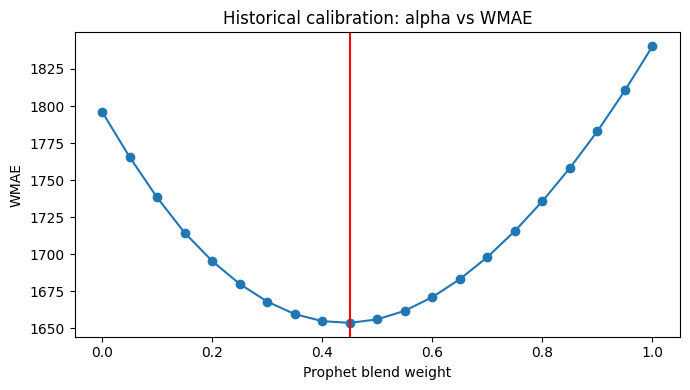

fit/elapsed_minutes,▁
fit/series_fallback,▁
fit/series_fit_ok,▁
fit/series_total,▁
tuning/best_alpha,▁
tuning/calibration_wmae,▁
validation/improvement_vs_v4_pct,▁
validation/raw_prophet_wmae,▁
validation/seasonal_naive_wmae,▁
validation/wmae,▁
fit/elapsed_minutes,35.32302


In [ ]:
run = wandb.init(
    entity=CONFIG["wandb_entity"],
    project=CONFIG["wandb_project"],
    group=CONFIG["wandb_group"],
    name=CONFIG["run_name"],
    job_type="hparam_tuning",
    tags=[
        "prophet",
        "v6",
        "historical-backtest",
        "alpha-tuning",
        "event-aware",
        "all-series",
    ],
    config=CONFIG,
    save_code=True,
)
val_path = OUTPUT_DIR / "prophet_v6_validation_predictions.csv"
alpha_path = OUTPUT_DIR / "prophet_v6_alpha_calibration.csv"
metrics_path = OUTPUT_DIR / "prophet_v6_metrics.json"
val_df.to_csv(val_path, index=False)
alpha_df.to_csv(alpha_path, index=False)
metrics_path.write_text(json.dumps(metrics, indent=2))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    alpha_df.sort_values("alpha").alpha,
    alpha_df.sort_values("alpha").calibration_wmae,
    marker="o",
)
ax.axvline(best_alpha, color="red")
ax.set_title("Historical calibration: alpha vs WMAE")
ax.set_xlabel("Prophet blend weight")
ax.set_ylabel("WMAE")
plt.tight_layout()
plot_path = OUTPUT_DIR / "prophet_v6_alpha_curve.png"
fig.savefig(plot_path, dpi=160)
plt.show()
artifact = wandb.Artifact(
    CONFIG["artifact_name"], type="model-evaluation", metadata={**CONFIG, **metrics}
)
for p in [val_path, alpha_path, metrics_path, plot_path]:
    artifact.add_file(str(p))
run.log_artifact(artifact, aliases=["v6", "validation", "latest"])
run.log(
    {
        **metrics,
        "tuning/alpha_table": wandb.Table(dataframe=alpha_df),
        "validation/predictions": wandb.Table(
            dataframe=val_df.sample(min(20000, len(val_df)), random_state=SEED)
        ),
        "tuning/alpha_curve": wandb.Image(str(plot_path)),
    }
)
run.summary.update(metrics)
run.finish()

## Package final v4 Prophet raw-input pipeline

This final section intentionally uses the selected v4 champion, not v5/v6. It refits each valid series on full train history, serializes fitted Prophet models, tests reload equivalence, and links the artifact to W&B Model Registry.


In [17]:
FINAL_V4_CONFIG = {
    "growth": "linear",
    "yearly_seasonality": True,
    "weekly_seasonality": False,
    "daily_seasonality": False,
    "seasonality_mode": "additive",
    "changepoint_prior_scale": 0.05,
    "seasonality_prior_scale": 10.0,
    "holidays_prior_scale": 10.0,
    "prediction_clip_min": 0.0,
    "prediction_clip_max": 300000.0,
    "seasonal_lag_weeks": 52,
    "blend_alpha": CONFIG["final_v4_alpha"],
}


class ProphetRawPipeline:
    """Fitted v4 Prophet ensemble accepting raw Walmart test.csv rows."""

    required_raw_columns = {"Store", "Dept", "Date", "IsHoliday"}

    def __init__(self, model_json_by_series, sales_history, event_calendar, config):
        self.model_json_by_series = dict(model_json_by_series)
        self.sales_history = sales_history[
            ["Store", "Dept", "Date", "Weekly_Sales"]
        ].copy()
        self.sales_history["Date"] = pd.to_datetime(self.sales_history["Date"])
        self.sales_history = self.sales_history.sort_values(["Store", "Dept", "Date"])
        self.event_calendar = event_calendar.copy()
        self.config = dict(config)
        self.series_index = pd.MultiIndex.from_frame(
            self.sales_history[["Store", "Dept"]]
            .drop_duplicates()
            .sort_values(["Store", "Dept"])
        )

    @staticmethod
    def _key(store, dept):
        return f"{int(store)}__{int(dept)}"

    def _seasonal_fallback(self, raw_test):
        test = raw_test.copy()
        test["Date"] = pd.to_datetime(test["Date"])
        history_dates = pd.Index(sorted(self.sales_history.Date.unique()))
        combined_dates = pd.Index(
            sorted(set(history_dates).union(set(test.Date.unique())))
        )
        panel = (
            self.sales_history.pivot_table(
                index=["Store", "Dept"],
                columns="Date",
                values="Weekly_Sales",
                aggfunc="sum",
            )
            .reindex(columns=history_dates)
            .fillna(0.0)
        )
        result = []
        for row in test.itertuples(index=False):
            pos = combined_dates.get_indexer([pd.Timestamp(row.Date)])[0]
            lag_pos = pos - int(self.config["seasonal_lag_weeks"])
            key = (int(row.Store), int(row.Dept))
            if lag_pos < 0 or key not in panel.index:
                result.append(0.0)
            else:
                lag_date = combined_dates[lag_pos]
                result.append(
                    float(panel.loc[key, lag_date])
                    if lag_date in panel.columns
                    else 0.0
                )
        return np.asarray(result, dtype=float)

    def predict(self, raw_test):
        missing = self.required_raw_columns.difference(raw_test.columns)
        if missing:
            raise ValueError({"missing_raw_test_columns": sorted(missing)})
        test = raw_test.copy()
        test["Date"] = pd.to_datetime(test["Date"])
        fallback = self._seasonal_fallback(test)
        result = fallback.copy()
        dates_by_series = test.groupby(["Store", "Dept"])["Date"].apply(
            lambda s: pd.Index(sorted(s.unique()))
        )
        for (store, dept), dates in dates_by_series.items():
            key = self._key(store, dept)
            if key not in self.model_json_by_series:
                continue
            model = model_from_json(self.model_json_by_series[key])
            forecast = model.predict(pd.DataFrame({"ds": dates}))
            values = np.clip(
                np.nan_to_num(
                    forecast["yhat"].to_numpy(float),
                    nan=0.0,
                    posinf=self.config["prediction_clip_max"],
                    neginf=0.0,
                ),
                self.config["prediction_clip_min"],
                self.config["prediction_clip_max"],
            )
            mask = (test.Store.astype(int) == int(store)) & (
                test.Dept.astype(int) == int(dept)
            )
            date_to_pred = dict(zip(dates, values))
            raw_idx = np.flatnonzero(mask.to_numpy())
            for i in raw_idx:
                raw_prophet = date_to_pred[pd.Timestamp(test.iloc[i].Date)]
                result[i] = (1 - self.config["blend_alpha"]) * fallback[
                    i
                ] + self.config["blend_alpha"] * raw_prophet
        return np.clip(
            result,
            self.config["prediction_clip_min"],
            self.config["prediction_clip_max"],
        )

    def metadata(self):
        return {
            "pipeline_type": type(self).__name__,
            "fitted_prophet_models": len(self.model_json_by_series),
            "stored_history_rows": len(self.sales_history),
            "blend_alpha": self.config["blend_alpha"],
            "raw_input_columns": sorted(self.required_raw_columns),
            "fallback": "52-week seasonal naive for sparse/cold-start series",
        }

In [18]:
if CONFIG["package_final_v4_pipeline"]:
    package_run = wandb.init(
        entity=CONFIG["wandb_entity"],
        project=CONFIG["wandb_project"],
        group="prophet-pipeline-packaging",
        job_type="pipeline_packaging",
        name="prophet_v4_raw_pipeline_registration",
        config={
            "source": CONFIG["final_v4_source"],
            "registry_target": CONFIG["final_pipeline_registry_target"],
        },
    )
    full_dates = pd.Index(sorted(train_raw.Date.unique()))
    full_panel = (
        train_raw.pivot_table(
            index=["Store", "Dept"],
            columns="Date",
            values="Weekly_Sales",
            aggfunc="sum",
        )
        .reindex(columns=full_dates)
        .fillna(0.0)
        .sort_index()
    )
    event_source = pd.concat(
        [train_raw[["Date", "IsHoliday"]], test_raw[["Date", "IsHoliday"]]]
    ).drop_duplicates("Date")
    final_holidays = event_source[event_source.IsHoliday].copy()
    final_holidays["ds"] = pd.to_datetime(final_holidays.Date)
    final_holidays["holiday"] = final_holidays.ds.map(event_name)
    final_holidays[["lower_window", "upper_window"]] = final_holidays.holiday.map(
        lambda x: HOLIDAY_WINDOWS.get(x, (0, 0))
    ).apply(pd.Series)
    final_holidays = final_holidays[["holiday", "ds", "lower_window", "upper_window"]]
    model_json_by_series = {}
    statuses = []
    start = time.time()
    for n, ((store, dept), series) in enumerate(full_panel.iterrows(), 1):
        history = pd.DataFrame({"ds": full_dates, "y": series.to_numpy(float)})
        history.y = history.y.clip(lower=0)
        if (history.y != 0).sum() >= 2:
            try:
                model = Prophet(
                    growth=FINAL_V4_CONFIG["growth"],
                    yearly_seasonality=FINAL_V4_CONFIG["yearly_seasonality"],
                    weekly_seasonality=False,
                    daily_seasonality=False,
                    seasonality_mode=FINAL_V4_CONFIG["seasonality_mode"],
                    changepoint_prior_scale=FINAL_V4_CONFIG["changepoint_prior_scale"],
                    seasonality_prior_scale=FINAL_V4_CONFIG["seasonality_prior_scale"],
                    holidays_prior_scale=FINAL_V4_CONFIG["holidays_prior_scale"],
                    holidays=final_holidays,
                )
                model.fit(history)
                model_json_by_series[ProphetRawPipeline._key(store, dept)] = (
                    model_to_json(model)
                )
                statuses.append("fit")
            except Exception:
                statuses.append("fallback_fit_error")
        else:
            statuses.append("fallback_insufficient_history")
        if n % 250 == 0 or n == len(full_panel):
            print(
                {
                    "final_refit_finished": n,
                    "elapsed_min": round((time.time() - start) / 60, 2),
                }
            )
    pipeline = ProphetRawPipeline(
        model_json_by_series, train_raw, final_holidays, FINAL_V4_CONFIG
    )
    pipeline_path = OUTPUT_DIR / "walmart_prophet_v4_raw_pipeline.pkl"
    with pipeline_path.open("wb") as f:
        cloudpickle.dump(pipeline, f)
    first = pipeline.predict(test_raw)
    with pipeline_path.open("rb") as f:
        reloaded = cloudpickle.load(f)
    second = reloaded.predict(test_raw)
    if (
        len(first) != len(test_raw)
        or not np.isfinite(first).all()
        or (first < 0).any()
        or not np.allclose(first, second, rtol=0, atol=1e-6)
    ):
        raise AssertionError("Prophet pipeline contract test failed")
    contract = test_raw[["Store", "Dept", "Date"]].copy()
    contract["Weekly_Sales"] = first
    contract_path = OUTPUT_DIR / "prophet_v4_pipeline_contract_predictions.csv"
    contract.to_csv(contract_path, index=False)
    manifest = {
        "source": "v4 champion",
        "validation_wmae": 1367.44697173274,
        "registry_target": CONFIG["final_pipeline_registry_target"],
        "contract_rows": len(first),
        "prediction_sha256": hashlib.sha256(first.tobytes()).hexdigest(),
        "fit_status": {
            "fit": int(sum(x == "fit" for x in statuses)),
            "fallback": int(sum(x != "fit" for x in statuses)),
        },
        **pipeline.metadata(),
    }
    manifest_path = OUTPUT_DIR / "prophet_v4_pipeline_manifest.json"
    manifest_path.write_text(json.dumps(manifest, indent=2))
    artifact = wandb.Artifact(
        CONFIG["final_pipeline_artifact_name"],
        type="model",
        description="Fitted v4 event-aware Prophet + SeasonalNaive52 raw-input pipeline.",
        metadata=manifest,
    )
    for file_path in [pipeline_path, contract_path, manifest_path]:
        artifact.add_file(str(file_path))
    package_run.log_artifact(artifact, aliases=["v4-champion", "latest"])
    package_run.link_artifact(
        artifact,
        target_path=CONFIG["final_pipeline_registry_target"],
        aliases=["champion", "v4-champion", "latest"],
    )
    package_run.log(
        {
            "pipeline/contract_predictions": wandb.Table(dataframe=contract.head(2000)),
            "pipeline/fitted_models": manifest["fitted_prophet_models"],
        }
    )
    package_run.summary.update(manifest)
    package_run.finish()
    print(
        {
            "registry_target": CONFIG["final_pipeline_registry_target"],
            **pipeline.metadata(),
        }
    )
else:
    print("Final Prophet pipeline packaging skipped")

{'final_refit_finished': 250, 'elapsed_min': 0.25}
{'final_refit_finished': 500, 'elapsed_min': 0.51}
{'final_refit_finished': 750, 'elapsed_min': 0.76}
{'final_refit_finished': 1000, 'elapsed_min': 1.01}
{'final_refit_finished': 1250, 'elapsed_min': 1.26}
{'final_refit_finished': 1500, 'elapsed_min': 1.52}
{'final_refit_finished': 1750, 'elapsed_min': 1.77}
{'final_refit_finished': 2000, 'elapsed_min': 2.02}
{'final_refit_finished': 2250, 'elapsed_min': 2.27}
{'final_refit_finished': 2500, 'elapsed_min': 2.53}
{'final_refit_finished': 2750, 'elapsed_min': 2.79}
{'final_refit_finished': 3000, 'elapsed_min': 3.04}
{'final_refit_finished': 3250, 'elapsed_min': 3.29}
{'final_refit_finished': 3331, 'elapsed_min': 3.36}


pipeline/fitted_models,▁
blend_alpha,0.5
contract_rows,115064
fallback,52-week seasonal nai...
fitted_prophet_models,3283
pipeline/fitted_models,3283
pipeline_type,ProphetRawPipeline
prediction_sha256,5242c83fb55f144e4a48...
registry_target,wandb-registry-model...
source,v4 champion
stored_history_rows,421570


{'registry_target': 'wandb-registry-model/Walmart_Prophet_Raw_Pipeline', 'pipeline_type': 'ProphetRawPipeline', 'fitted_prophet_models': 3283, 'stored_history_rows': 421570, 'blend_alpha': 0.5, 'raw_input_columns': ['Date', 'Dept', 'IsHoliday', 'Store'], 'fallback': '52-week seasonal naive for sparse/cold-start series'}
